In [10]:
from sklearn.datasets import load_iris

In [11]:
from sklearn.model_selection import train_test_split
import pandas as pd

In [12]:
X,y = load_iris(return_X_y=True)
pd.DataFrame(X)

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [14]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [ ]:
# Is the data Gaussian? GaussianNB assumes each FEATURE is normal WITHIN EACH CLASS
import matplotlib.pyplot as plt
import seaborn as sns

iris = load_iris()
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(y, iris.target_names)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.ravel(), iris.feature_names):
    for name in iris.target_names:
        sns.kdeplot(data=df[df['species'] == name], x=col, fill=True, alpha=0.35,
                    label=name, ax=ax)
    ax.set_title(col)
    ax.legend()

plt.suptitle('Per-class distribution of each feature (should look bell shaped)')
plt.tight_layout()
plt.show()


In [ ]:
# Histogram + fitted normal curve for each feature within each class
import numpy as np
from scipy.stats import norm

fig, axes = plt.subplots(4, 3, figsize=(14, 14))

for i, col in enumerate(iris.feature_names):
    for j, name in enumerate(iris.target_names):
        ax = axes[i, j]
        vals = df.loc[df['species'] == name, col]

        ax.hist(vals, bins=10, density=True, alpha=0.5, edgecolor='k')

        xs = np.linspace(vals.min(), vals.max(), 200)
        ax.plot(xs, norm.pdf(xs, vals.mean(), vals.std()), 'r')

        ax.set_title(f'{col}
{name}', fontsize=9)

plt.suptitle('Histogram vs fitted normal (red curve)')
plt.tight_layout()
plt.show()


In [ ]:
# Q-Q plots: points on the straight line = Gaussian
from scipy import stats

fig, axes = plt.subplots(4, 3, figsize=(14, 14))

for i, col in enumerate(iris.feature_names):
    for j, name in enumerate(iris.target_names):
        ax = axes[i, j]
        vals = df.loc[df['species'] == name, col]
        stats.probplot(vals, dist='norm', plot=ax)
        ax.set_title(f'{col}
{name}', fontsize=9)

plt.suptitle('Q-Q plots')
plt.tight_layout()
plt.show()


In [ ]:
# Shapiro-Wilk test: p > 0.05 means we cannot reject normality (i.e. it looks Gaussian)
from scipy.stats import shapiro

rows = []
for col in iris.feature_names:
    for name in iris.target_names:
        stat, p = shapiro(df.loc[df['species'] == name, col])
        rows.append([col, name, round(p, 4), 'Gaussian' if p > 0.05 else 'Not Gaussian'])

pd.DataFrame(rows, columns=['feature', 'species', 'p_value', 'verdict'])


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [17]:
gnb = GaussianNB()

In [18]:
gnb.fit(X_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](3,)","[36.,33.,36.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](3,)","[0.34,0.31,0.34]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](3,)","[0,1,2]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,3.142e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](3, 4)","[[5.05,3.48,1.46,0.24], [5.95,2.77,4.21,1.32], [6.54,2.98,5.54,2.01]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](3, 4)","[[0.14,0.13,0.03,0.01], [0.28,0.08,0.26,0.04], [0.41,0.1 ,0.28,0.08]]"


In [19]:
y_pred = gnb.predict(X_test)

In [20]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [21]:
print(confusion_matrix(y_pred,y_test))
print(accuracy_score(y_pred,y_test))
print(classification_report(y_pred,y_test))

[[14  0  0]
 [ 0 17  0]
 [ 0  0 14]]
1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00        17
           2       1.00      1.00      1.00        14

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

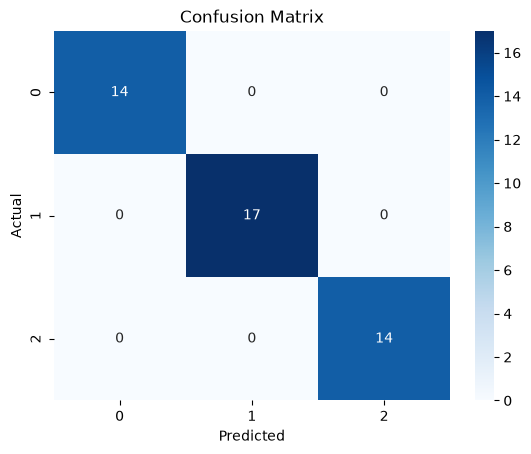

In [23]:
# 1. Confusion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

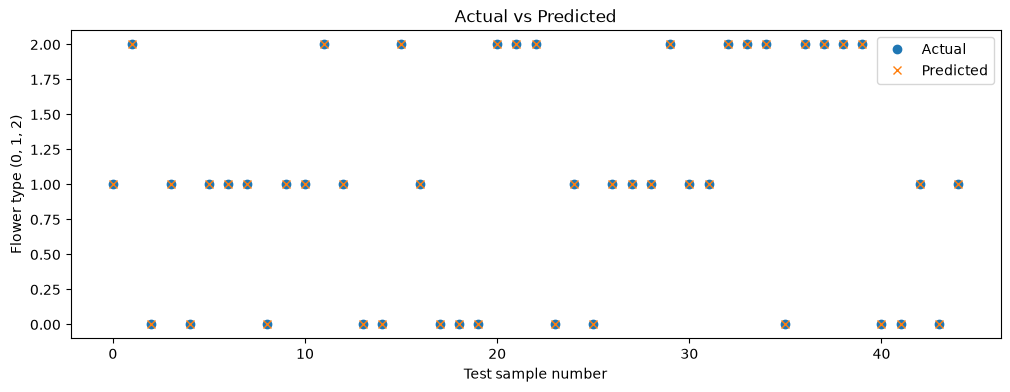

In [24]:
# 2. Actual vs Predicted
plt.figure(figsize=(12, 4))

plt.plot(y_test, 'o', label='Actual')
plt.plot(y_pred, 'x', label='Predicted')

plt.xlabel('Test sample number')
plt.ylabel('Flower type (0, 1, 2)')
plt.title('Actual vs Predicted')
plt.legend()
plt.show()

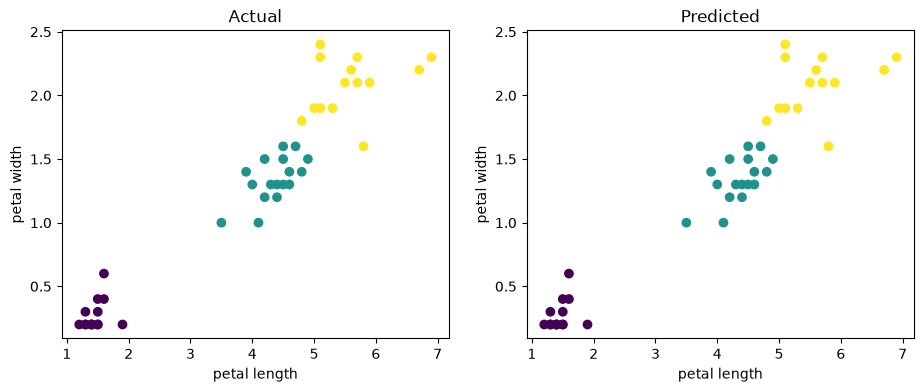

In [25]:
# 3. Scatter plot: petal length vs petal width
plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
plt.scatter(X_test[:, 2], X_test[:, 3], c=y_test)
plt.xlabel('petal length')
plt.ylabel('petal width')
plt.title('Actual')

plt.subplot(1, 2, 2)
plt.scatter(X_test[:, 2], X_test[:, 3], c=y_pred)
plt.xlabel('petal length')
plt.ylabel('petal width')
plt.title('Predicted')

plt.show()

In [26]:
import seaborn as sns

In [27]:
sns.load_dataset('tips')

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
